In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("train.csv")
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
df = df.drop(["Cabin", "Embarked"], axis=1)

KeyError: "['Cabin', 'Embarked'] not found in axis"

In [11]:
avg_age = df["Age"].median()
df["Age"] = df["Age"].fillna(avg_age)


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64

In [14]:
gender_map = {"male": 0, "female": 1}
df["Sex"] = df["Sex"].map(gender_map) 


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833
2,3,1,3,1,26.0,0,0,7.9250
3,4,1,1,1,35.0,1,0,53.1000
4,5,0,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000
887,888,1,1,1,19.0,0,0,30.0000
888,889,0,3,1,28.0,1,2,23.4500
889,890,1,1,0,26.0,0,0,30.0000


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(["Survived"], axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, stratify=y, random_state=1
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
print(f"Real Accuracy: {model.score(X_test, y_test) * 100}%")

Real Accuracy: 79.8507462686567%


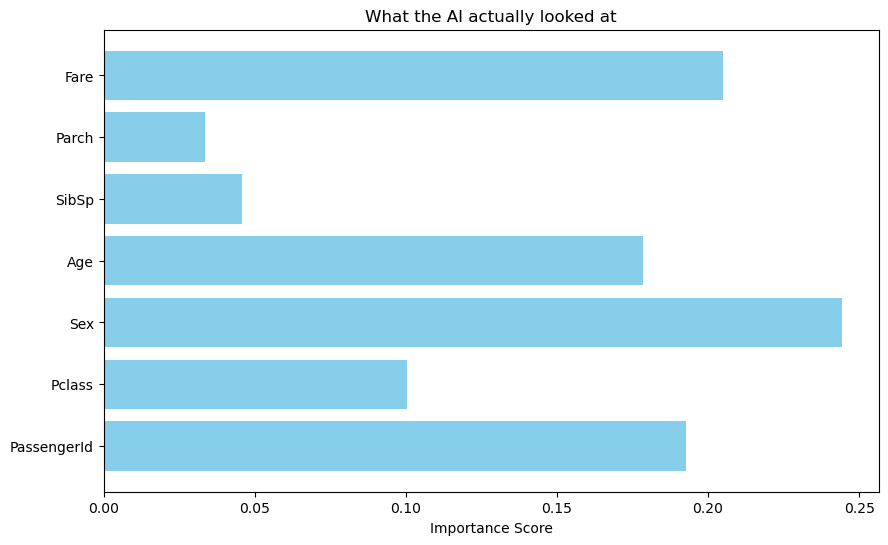

In [22]:
import matplotlib.pyplot as plt

# Get the names of the columns we used
features = X.columns
# Get how much the AI cared about each one
importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='skyblue')
plt.xlabel("Importance Score")
plt.title("What the AI actually looked at")
plt.show()